In [15]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

## Green functions and transmissivity

In [16]:
@dataclass
class ChannelParams:
    gamma_A: float
    gamma_B: float
    omega_A: float
    omega_B: float
    sigma: float
    d: float
    m_A: float = 1.0
    m_B: float = 1.0
    E: float = 100.0

    @property
    def Sigma2_A(self):
        return np.sqrt(8 / np.pi) * self.gamma_A / self.sigma - self.omega_A**2

    @property
    def Sigma2_B(self):
        return np.sqrt(8 / np.pi) * self.gamma_B / self.sigma - self.omega_B**2

    @property
    def coupling_delay(self):
        return 2 * np.sqrt(self.gamma_A * self.gamma_B) / self.d

In [46]:
params = ChannelParams(
    gamma_A=0.010,
    gamma_B=0.010,
    omega_A=1.0,
    omega_B=1.0,
    sigma=0.01,
    d=1.0,
    m_A=1.0,
    m_B=1.0,
    E=100.0,
)

print("Sigma_A^2 =", params.Sigma2_A)
print("Sigma_B^2 =", params.Sigma2_B)

Sigma_A^2 = 0.5957691216057306
Sigma_B^2 = 0.5957691216057306


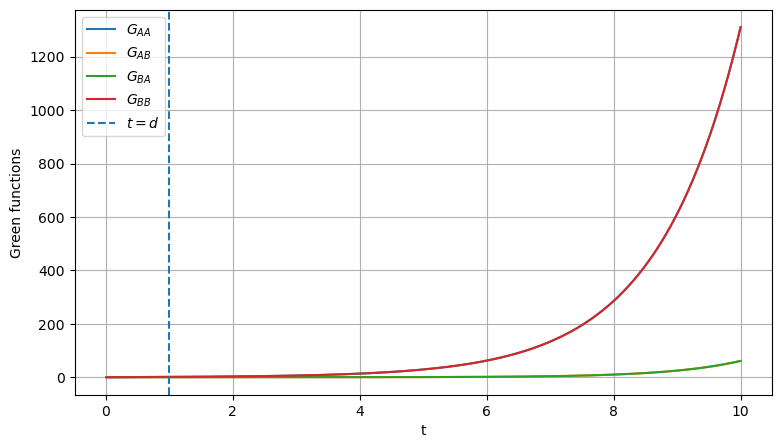

In [47]:
#
def solve_green_functions(params, t_max, dt=0.01, rtol=1e-8, atol=1e-10):
    """
    Solves the delayed Green-function system Eq. (43) with method of steps.

    State vector:
        y = (G_AA, dG_AA, G_AB, dG_AB, G_BA, dG_BA, G_BB, dG_BB)

    Initial conditions:
        G_AA(0)=G_AB(0)=G_BA(0)=G_BB(0)=0
        dG_AA(0)=1
        dG_BB(0)=1
        dG_AB(0)=dG_BA(0)=0
    """

    d = params.d
    kappa = params.coupling_delay

    Sigma2_A = params.Sigma2_A
    Sigma2_B = params.Sigma2_B
    gamma_A = params.gamma_A
    gamma_B = params.gamma_B

    y0 = np.array([
        0.0, 1.0,   # G_AA, dG_AA
        0.0, 0.0,   # G_AB, dG_AB
        0.0, 0.0,   # G_BA, dG_BA
        0.0, 1.0,   # G_BB, dG_BB
    ])

    all_t = []
    all_y = []

    t_known = np.array([0.0])
    y_known = y0.reshape(8, 1)

    def make_history_interpolator(t_known, y_known):
        """
        Returns function hist(t_delay) giving delayed G values.

        For t_delay < 0, Green functions are zero.
        """

        if len(t_known) == 1:

            def hist_single_point(t_delay):
                if t_delay < 0:
                    return {
                        "G_AA": 0.0,
                        "G_AB": 0.0,
                        "G_BA": 0.0,
                        "G_BB": 0.0,
                    }

                return {
                    "G_AA": float(y_known[0, 0]),
                    "G_AB": float(y_known[2, 0]),
                    "G_BA": float(y_known[4, 0]),
                    "G_BB": float(y_known[6, 0]),
                }

            return hist_single_point

        interp_kind = "cubic" if len(t_known) >= 4 else "linear"

        interpolators = [
            interp1d(
                t_known,
                y_known[i],
                kind=interp_kind,
                bounds_error=False,
                fill_value=(y_known[i, 0], y_known[i, -1]),
            )
            for i in range(y_known.shape[0])
        ]

        def hist(t_delay):
            if t_delay < 0:
                return {
                    "G_AA": 0.0,
                    "G_AB": 0.0,
                    "G_BA": 0.0,
                    "G_BB": 0.0,
                }

            vals = [float(interp(t_delay)) for interp in interpolators]

            return {
                "G_AA": vals[0],
                "G_AB": vals[2],
                "G_BA": vals[4],
                "G_BB": vals[6],
            }

        return hist

    current_t0 = 0.0
    current_y0 = y0.copy()

    while current_t0 < t_max:
        current_t1 = min(current_t0 + d, t_max)

        hist = make_history_interpolator(t_known, y_known)

        def rhs(t, y):
            G_AA, v_AA, G_AB, v_AB, G_BA, v_BA, G_BB, v_BB = y

            delayed = hist(t - d)

            theta = 1.0 if t >= d else 0.0

            rhs_AA = kappa * delayed["G_BA"] * theta
            rhs_AB = kappa * delayed["G_BB"] * theta
            rhs_BA = kappa * delayed["G_AA"] * theta
            rhs_BB = kappa * delayed["G_AB"] * theta

            a_AA = Sigma2_A * G_AA - 2 * gamma_A * v_AA + rhs_AA
            a_AB = Sigma2_A * G_AB - 2 * gamma_A * v_AB + rhs_AB
            a_BA = Sigma2_B * G_BA - 2 * gamma_B * v_BA + rhs_BA
            a_BB = Sigma2_B * G_BB - 2 * gamma_B * v_BB + rhs_BB

            return np.array([
                v_AA, a_AA,
                v_AB, a_AB,
                v_BA, a_BA,
                v_BB, a_BB,
            ])

        t_eval = np.arange(current_t0, current_t1 + 0.5 * dt, dt)
        t_eval = t_eval[t_eval <= current_t1]

        sol = solve_ivp(
            rhs,
            (current_t0, current_t1),
            current_y0,
            t_eval=t_eval,
            rtol=rtol,
            atol=atol,
            method="DOP853",
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        # Avoid duplicating the first point of every segment,
        # including the very first t=0 point already stored in t_known.
        seg_t = sol.t[1:]
        seg_y = sol.y[:, 1:]

        if len(seg_t) > 0:
            all_t.append(seg_t)
            all_y.append(seg_y)

            t_known = np.concatenate([t_known, seg_t])
            y_known = np.concatenate([y_known, seg_y], axis=1)

        current_t0 = current_t1
        current_y0 = sol.y[:, -1]

    t = np.concatenate(all_t)
    y = np.concatenate(all_y, axis=1)

    return t, y

t_max = 10.0
dt = 0.01

t, y = solve_green_functions(params, t_max=t_max, dt=dt)

G_AA, dG_AA = y[0], y[1]
G_AB, dG_AB = y[2], y[3]
G_BA, dG_BA = y[4], y[5]
G_BB, dG_BB = y[6], y[7]

plt.figure(figsize=(9, 5))
plt.plot(t, G_AA, label=r"$G_{AA}$")
plt.plot(t, G_AB, label=r"$G_{AB}$")
plt.plot(t, G_BA, label=r"$G_{BA}$")
plt.plot(t, G_BB, label=r"$G_{BB}$")
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel("Green functions")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
mask_before_causal = t < params.d

print("max |G_BA(t<d)| =", np.max(np.abs(G_BA[mask_before_causal])))
print("max |G_AB(t<d)| =", np.max(np.abs(G_AB[mask_before_causal])))

max |G_BA(t<d)| = 0.0
max |G_AB(t<d)| = 0.0


In [49]:
def compute_ddot_G_BA(t, G_BA, dG_BA, G_AA, params):
    d = params.d
    kappa = params.coupling_delay

    # delayed G_AA(t-d)
    interp_G_AA = interp1d(
        t,
        G_AA,
        kind="cubic",
        bounds_error=False,
        fill_value=(G_AA[0], G_AA[-1])
    )

    G_AA_delay = np.zeros_like(t)
    mask = t >= d
    G_AA_delay[mask] = interp_G_AA(t[mask] - d)

    ddG_BA = (
        params.Sigma2_B * G_BA
        - 2 * params.gamma_B * dG_BA
        + kappa * G_AA_delay
    )

    return ddG_BA


ddG_BA = compute_ddot_G_BA(t, G_BA, dG_BA, G_AA, params)

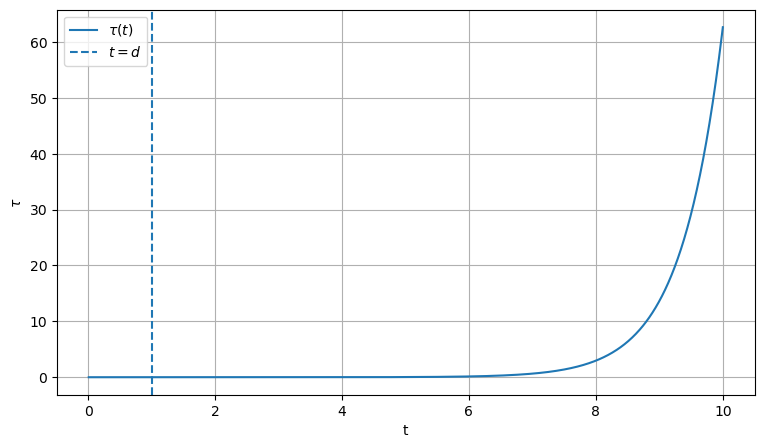

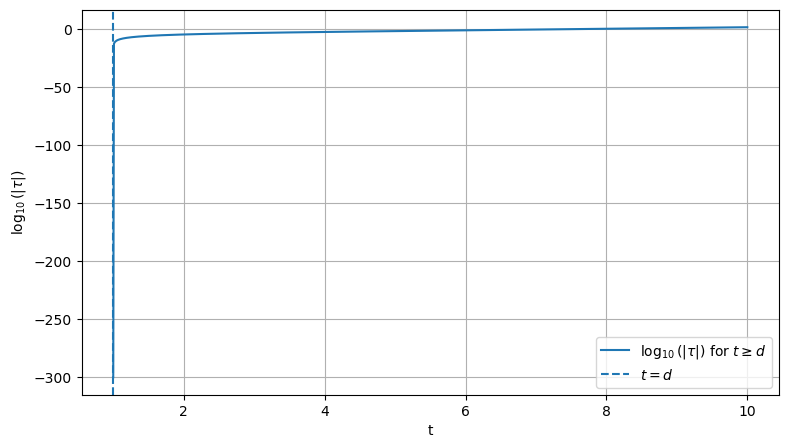

max |tau(t<d)| = 0.0
min tau = 0.0
max tau = 62.65246640493251
max |tau| = 62.65246640493251


In [50]:
def compute_tau(t, G_BA, dG_BA, ddG_BA, params):
    tau = (params.omega_A / params.omega_B) * (dG_BA**2 - G_BA * ddG_BA)
    return tau


tau = compute_tau(t, G_BA, dG_BA, ddG_BA, params)

plt.figure(figsize=(9, 5))
plt.plot(t, tau, label=r"$\tau(t)$")
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel(r"$\tau$")
plt.legend()
plt.grid(True)
plt.show()


mask_after_causal = t >= params.d
tau_abs_after = np.abs(tau[mask_after_causal])

plt.figure(figsize=(9, 5))
plt.plot(
    t[mask_after_causal],
    np.log10(tau_abs_after + 1e-300),
    label=r"$\log_{10}(|\tau|)$ for $t \geq d$",
)
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel(r"$\log_{10}(|\tau|)$")
plt.legend()
plt.grid(True)
plt.show()

print("max |tau(t<d)| =", np.max(np.abs(tau[mask_before_causal])))
print("min tau =", np.min(tau))
print("max tau =", np.max(tau))
print("max |tau| =", np.max(np.abs(tau)))

## Noise

In [51]:
#
from scipy.special import dawsn

#
def lambda_from_gamma(gamma, mass):
    return np.sqrt(8.0 * np.pi * mass * gamma)


def nu_AA(delta, params):
    """
    Noise kernel nu_AA(delta), Eq. (41).
    delta can be a scalar or NumPy array.
    """

    lam_A = lambda_from_gamma(params.gamma_A, params.m_A)
    sigma = params.sigma

    x = delta / (np.sqrt(2.0) * sigma)

    return (
        lam_A**2
        / (8.0 * np.pi**2 * sigma**2)
        * (1.0 - (np.sqrt(2.0) * delta / sigma) * dawsn(x))
    )


def nu_BB(delta, params):
    """
    Noise kernel nu_BB(delta), Eq. (41).
    delta can be a scalar or NumPy array.
    """

    lam_B = lambda_from_gamma(params.gamma_B, params.m_B)
    sigma = params.sigma

    x = delta / (np.sqrt(2.0) * sigma)

    return (
        lam_B**2
        / (8.0 * np.pi**2 * sigma**2)
        * (1.0 - (np.sqrt(2.0) * delta / sigma) * dawsn(x))
    )


def nu_AB(delta, params):
    """
    Noise kernel nu_AB(delta)=nu_BA(delta), Eq. (42).
    delta can be a scalar or NumPy array.
    """

    lam_A = lambda_from_gamma(params.gamma_A, params.m_A)
    lam_B = lambda_from_gamma(params.gamma_B, params.m_B)

    sigma = params.sigma
    d = params.d

    x_plus = (delta + d) / (np.sqrt(2.0) * sigma)
    x_minus = (delta - d) / (np.sqrt(2.0) * sigma)

    return (
        np.sqrt(2.0)
        * lam_A
        * lam_B
        / (8.0 * np.pi**2 * sigma * d)
        * (dawsn(x_plus) - dawsn(x_minus))
    )


def nu_BA(delta, params):
    """
    In this static Minkowski setup, nu_BA = nu_AB.
    """

    return nu_AB(delta, params)

#
def build_full_green_arrays(t, y):
    """
    Adds the exact t=0 initial conditions to the Green-function arrays.
    """

    y0 = np.array([
        0.0, 1.0,
        0.0, 0.0,
        0.0, 0.0,
        0.0, 1.0,
    ])

    t_full = np.concatenate([[0.0], t])
    y_full = np.concatenate([y0.reshape(8, 1), y], axis=1)

    return t_full, y_full


t_full, y_full = build_full_green_arrays(t, y)

G_AA_full, dG_AA_full = y_full[0], y_full[1]
G_AB_full, dG_AB_full = y_full[2], y_full[3]
G_BA_full, dG_BA_full = y_full[4], y_full[5]
G_BB_full, dG_BB_full = y_full[6], y_full[7]

#
def make_green_interpolators(t_full, y_full):
    """
    Creates cubic interpolators for G and dG.
    """

    names = [
        "G_AA", "dG_AA",
        "G_AB", "dG_AB",
        "G_BA", "dG_BA",
        "G_BB", "dG_BB",
    ]

    interpolators = {}

    for i, name in enumerate(names):
        interpolators[name] = interp1d(
            t_full,
            y_full[i],
            kind="cubic",
            bounds_error=False,
            fill_value=(y_full[i, 0], y_full[i, -1]),
        )

    return interpolators


green_interp = make_green_interpolators(t_full, y_full)

In [52]:
#
def compute_ddot_G_BB_values(t_values, green_interp, params):
    """
    Computes ddot G_BB(t) directly from Eq. (43):

    ddot G_BB =
        Sigma_B^2 G_BB
        - 2 gamma_B dot G_BB
        + kappa G_AB(t-d) theta(t-d)
    """

    t_values = np.asarray(t_values)

    G_BB_vals = green_interp["G_BB"](t_values)
    dG_BB_vals = green_interp["dG_BB"](t_values)

    delayed_argument = t_values - params.d
    G_AB_delay = np.zeros_like(t_values, dtype=float)

    mask = delayed_argument >= 0.0
    G_AB_delay[mask] = green_interp["G_AB"](delayed_argument[mask])

    ddG_BB_vals = (
        params.Sigma2_B * G_BB_vals
        - 2.0 * params.gamma_B * dG_BB_vals
        + params.coupling_delay * G_AB_delay
    )

    return ddG_BB_vals

#
def compute_N_initial_Bob(T, green_interp, params):
    """
    Computes the Bob-initial-state contribution to N from Eq. (32).

    Bob starts in the ground state:
        sigma_BB(0) = 1/2 I.
    """

    G_BB = float(green_interp["G_BB"](T))
    dG_BB = float(green_interp["dG_BB"](T))
    ddG_BB = float(compute_ddot_G_BB_values(np.array([T]), green_interp, params)[0])

    omega_B = params.omega_B

    A = np.array([
        [dG_BB, omega_B * G_BB],
        [ddG_BB / omega_B, dG_BB],
    ])

    sigma_BB_0 = 0.5 * np.eye(2)

    return A @ sigma_BB_0 @ A.T

#
def trapezoid_weights(x):
    """
    Trapezoidal integration weights for a 1D grid.
    """

    x = np.asarray(x)

    if len(x) == 1:
        return np.array([0.0])

    w = np.zeros_like(x, dtype=float)

    w[0] = 0.5 * (x[1] - x[0])
    w[-1] = 0.5 * (x[-1] - x[-2])
    w[1:-1] = 0.5 * (x[2:] - x[:-2])

    return w


def compute_Nprime_B(T, green_interp, params, n_integral_points=None):
    """
    Computes N'_B(T), the noise contribution from the field.

    This uses the compact static version of Eqs. (28)-(30).

    Output:
        2x2 matrix:
            [[N11, N12],
             [N12, N22]]
    """

    if T <= 0.0:
        return np.zeros((2, 2))

    if n_integral_points is None:
        n_integral_points = max(2, int(np.ceil(T / 0.01)) + 1)

    r = np.linspace(0.0, T, n_integral_points)
    w = trapezoid_weights(r)
    W2 = np.outer(w, w)

    u = T - r

    G_BA_u = green_interp["G_BA"](u)
    G_BB_u = green_interp["G_BB"](u)

    dG_BA_u = green_interp["dG_BA"](u)
    dG_BB_u = green_interp["dG_BB"](u)

    G_row = [
        G_BA_u,
        G_BB_u,
    ]

    dG_row = [
        dG_BA_u,
        dG_BB_u,
    ]

    delta = r[:, None] - r[None, :]

    nu = [
        [nu_AA(delta, params), nu_AB(delta, params)],
        [nu_BA(delta, params), nu_BB(delta, params)],
    ]

    scale = [
        np.sqrt(params.omega_A / params.m_A),
        np.sqrt(params.omega_B / params.m_B),
    ]

    K = [
        [scale[i] * nu[i][j] * scale[j] for j in range(2)]
        for i in range(2)
    ]

    def double_integral(x_list, y_list):
        value = 0.0

        for i in range(2):
            for j in range(2):
                value += np.sum(
                    W2
                    * x_list[i][:, None]
                    * K[i][j]
                    * y_list[j][None, :]
                )

        return value

    N11 = double_integral(G_row, G_row)
    N12 = double_integral(G_row, dG_row) / params.omega_B
    N22 = double_integral(dG_row, dG_row) / params.omega_B**2

    return np.array([
        [N11, N12],
        [N12, N22],
    ])

In [53]:
#
def compute_N_and_W(T, green_interp, params, n_integral_points=None):
    """
    Computes total N(T) and W(T)=det N(T).
    """

    N_initial = compute_N_initial_Bob(T, green_interp, params)
    N_prime = compute_Nprime_B(
        T,
        green_interp,
        params,
        n_integral_points=n_integral_points,
    )

    N_total = N_initial + N_prime
    W_det = np.linalg.det(N_total)

    return N_total, W_det

#
test_times = np.array([
    0.5 * params.d,
    params.d,
    2.0 * params.d,
    5.0 * params.d,
    10.0 * params.d,
])

test_times = test_times[test_times <= t_max]

for T in test_times:
    N_T, W_T = compute_N_and_W(
        T,
        green_interp,
        params,
        n_integral_points=300,
    )

    print(f"T = {T:.3f}")
    print("N =")
    print(N_T)
    print("W =", W_T)
    print("sqrt(W) =", np.sqrt(W_T) if W_T >= 0 else np.nan)
    print("-" * 50)

T = 0.500
N =
[[0.7003977  0.42965293]
 [0.42965293 0.63732611]]
W = 0.26178009683980696
sqrt(W) = 0.51164450240358
--------------------------------------------------
T = 1.000
N =
[[1.44366513 1.12766031]
 [1.12766031 1.06762035]]
W = 0.26966850942818055
sqrt(W) = 0.5192961673536408
--------------------------------------------------
T = 2.000
N =
[[6.90819395 5.37698722]
 [5.37698722 4.23516182]]
W = 0.34532774260689303
sqrt(W) = 0.5876459330301649
--------------------------------------------------
T = 5.000
N =
[[681.11435088 519.15958774]
 [519.15958774 395.73355868]]
W = 13.12840347438503
sqrt(W) = 3.623313880191037
--------------------------------------------------
T = 10.000
N =
[[2104718.61750239 1604349.06845645]
 [1604349.06845645 1222963.43415569]]
W = 57974935.064226694
sqrt(W) = 7614.12733438486
--------------------------------------------------


In [54]:
#
n_noise_times = 100

noise_times = np.linspace(0.0, t_max, n_noise_times)

W_values = np.zeros_like(noise_times)
N_values = []

for idx, T in enumerate(noise_times):
    N_T, W_T = compute_N_and_W(
        T,
        green_interp,
        params,
        n_integral_points=300,
    )

    N_values.append(N_T)
    W_values[idx] = W_T

    if idx % 10 == 0:
        print(f"Computed {idx + 1}/{len(noise_times)} noise points")

N_values = np.array(N_values)

print("Done.")

Computed 1/100 noise points
Computed 11/100 noise points
Computed 21/100 noise points
Computed 31/100 noise points
Computed 41/100 noise points
Computed 51/100 noise points
Computed 61/100 noise points
Computed 71/100 noise points
Computed 81/100 noise points
Computed 91/100 noise points
Done.


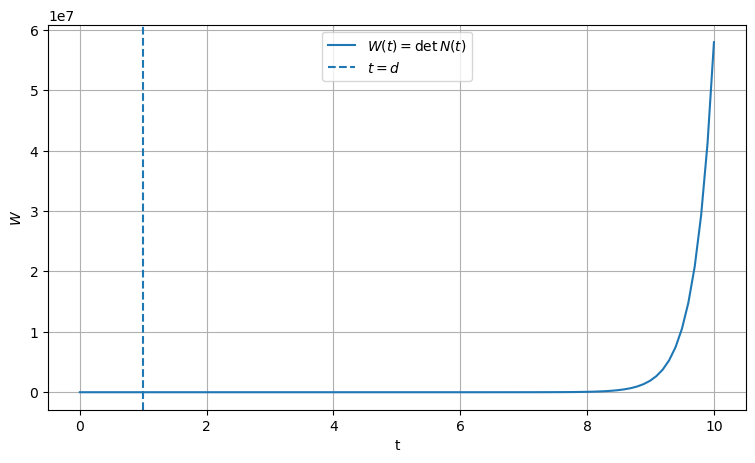

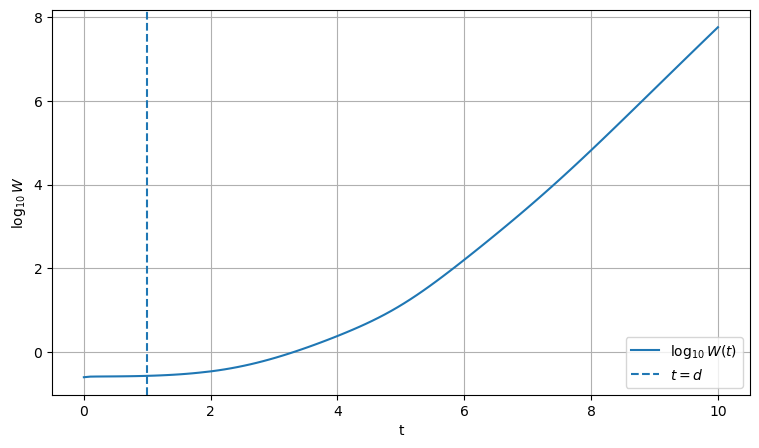

In [55]:
#
plt.figure(figsize=(9, 5))
plt.plot(noise_times, W_values, label=r"$W(t)=\det N(t)$")
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel(r"$W$")
plt.legend()
plt.grid(True)
plt.show()


mask_W_positive = W_values > 0

plt.figure(figsize=(9, 5))
plt.plot(
    noise_times[mask_W_positive],
    np.log10(W_values[mask_W_positive]),
    label=r"$\log_{10} W(t)$",
)
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel(r"$\log_{10} W$")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
#
print("min W =", np.min(W_values))
print("max W =", np.max(W_values))
print("number of negative W values =", np.sum(W_values < 0))

print("min N11 =", np.min(N_values[:, 0, 0]))
print("min N22 =", np.min(N_values[:, 1, 1]))
print("max |N12| =", np.max(np.abs(N_values[:, 0, 1])))

min W = 0.25
max W = 57974935.064226694
number of negative W values = 0
min N11 = 0.5
min N22 = 0.5002
max |N12| = 1604349.0684564463


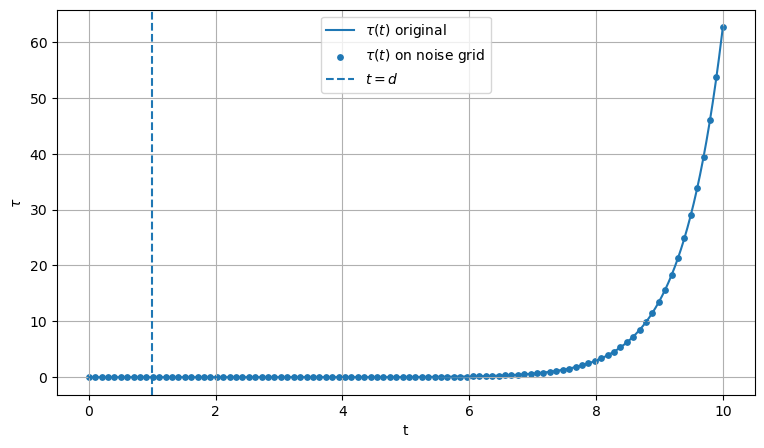

In [57]:
#
def h_bosonic(x):
    """
    h(x) = (x+1/2) log2(x+1/2) - (x-1/2) log2(x-1/2)

    Stable implementation using n = x - 1/2:

        h = (n+1)log2(n+1) - n log2(n)

    rewritten as:

        h = [log(n+1) + n log(1 + 1/n)] / log(2)

    Domain: x >= 1/2.
    """

    x = np.asarray(x, dtype=float)
    n = x - 0.5

    out = np.full_like(x, np.nan, dtype=float)

    mask_zero = np.isclose(n, 0.0, atol=1e-15, rtol=0.0)
    mask_pos = n > 0.0

    out[mask_zero] = 0.0

    n_pos = n[mask_pos]
    out[mask_pos] = (
        np.log1p(n_pos) + n_pos * np.log1p(1.0 / n_pos)
    ) / np.log(2.0)

    if out.shape == ():
        return float(out)

    return out

#
tau_full = np.concatenate([[0.0], tau])

tau_interp = interp1d(
    t_full,
    tau_full,
    kind="cubic",
    bounds_error=False,
    fill_value=(tau_full[0], tau_full[-1]),
)

tau_on_noise_times = tau_interp(noise_times)

#
plt.figure(figsize=(9, 5))
plt.plot(t, tau, label=r"$\tau(t)$ original")
plt.scatter(
    noise_times,
    tau_on_noise_times,
    s=15,
    label=r"$\tau(t)$ on noise grid",
)
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel(r"$\tau$")
plt.legend()
plt.grid(True)
plt.show()

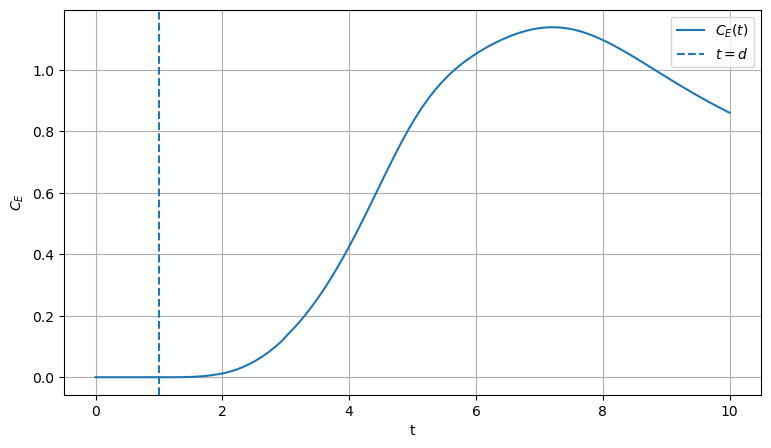

In [58]:
#
def compute_capacity_E(tau_values, W_values, params):
    """
    Energy-constrained classical capacity:

    C_E = h(E/omega_A * |tau| + sqrt(W))
          - h(|tau|/2 + sqrt(W))
    """

    tau_abs = np.abs(np.asarray(tau_values, dtype=float))
    W_values = np.asarray(W_values, dtype=float)

    C = np.full_like(tau_abs, np.nan, dtype=float)

    mask_valid = W_values >= 0.0

    sqrt_W = np.full_like(W_values, np.nan, dtype=float)
    sqrt_W[mask_valid] = np.sqrt(W_values[mask_valid])

    x1 = params.E / params.omega_A * tau_abs + sqrt_W
    x2 = 0.5 * tau_abs + sqrt_W

    C[mask_valid] = h_bosonic(x1[mask_valid]) - h_bosonic(x2[mask_valid])

    # Remove tiny negative numerical values
    tiny_negative = (C < 0.0) & (C > -1e-10)
    C[tiny_negative] = 0.0

    return C


C_values = compute_capacity_E(tau_on_noise_times, W_values, params)

plt.figure(figsize=(9, 5))
plt.plot(noise_times, C_values, label=r"$C_E(t)$")
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel(r"$C_E$")
plt.legend()
plt.grid(True)
plt.show()

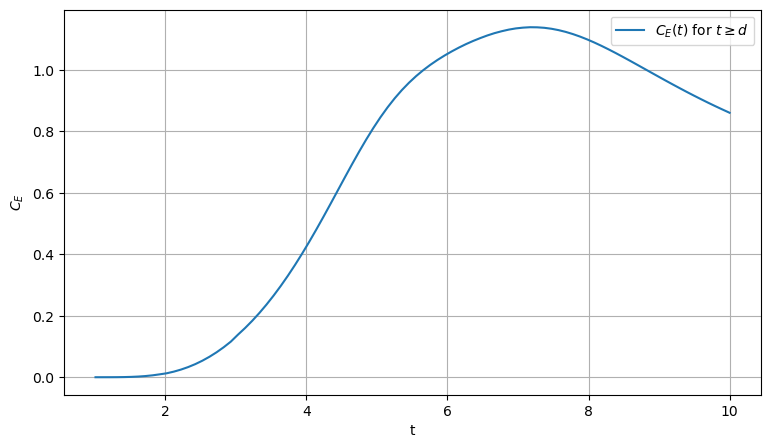

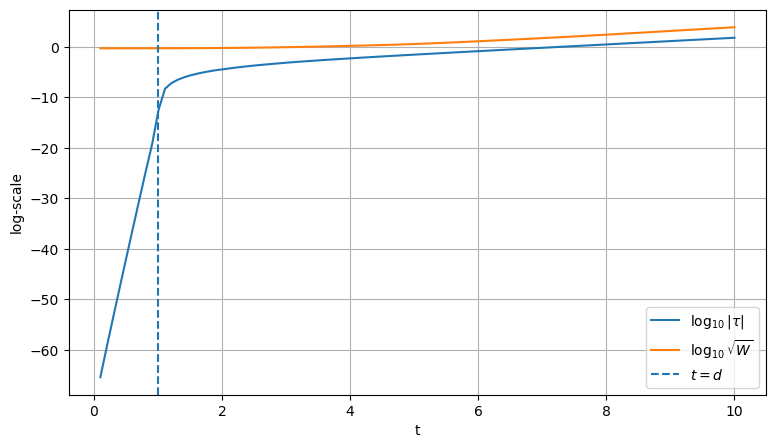

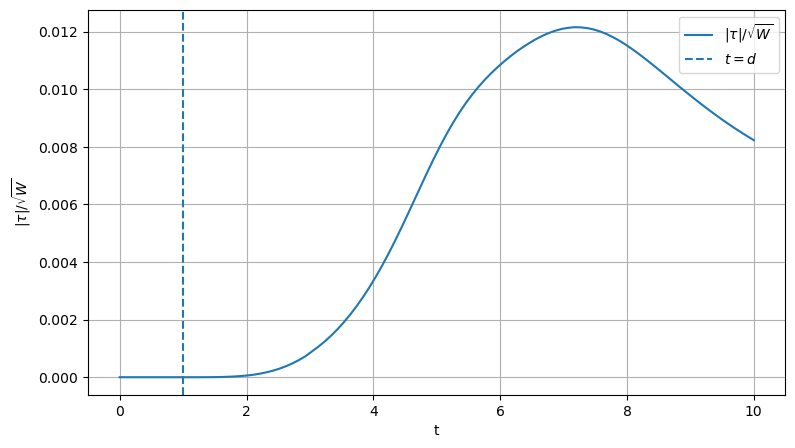

In [59]:
#
mask_after_causal_noise = noise_times >= params.d

plt.figure(figsize=(9, 5))
plt.plot(
    noise_times[mask_after_causal_noise],
    C_values[mask_after_causal_noise],
    label=r"$C_E(t)$ for $t\geq d$",
)
plt.xlabel("t")
plt.ylabel(r"$C_E$")
plt.legend()
plt.grid(True)
plt.show()

#
mask_positive = (W_values > 0.0) & (np.abs(tau_on_noise_times) > 0.0)

plt.figure(figsize=(9, 5))
plt.plot(
    noise_times[mask_positive],
    np.log10(np.abs(tau_on_noise_times[mask_positive])),
    label=r"$\log_{10}|\tau|$",
)
plt.plot(
    noise_times[mask_positive],
    0.5 * np.log10(W_values[mask_positive]),
    label=r"$\log_{10}\sqrt{W}$",
)
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel("log-scale")
plt.legend()
plt.grid(True)
plt.show()

#
ratio_tau_sqrtW = np.full_like(W_values, np.nan, dtype=float)

mask_ratio = W_values > 0.0
ratio_tau_sqrtW[mask_ratio] = np.abs(tau_on_noise_times[mask_ratio]) / np.sqrt(W_values[mask_ratio])

plt.figure(figsize=(9, 5))
plt.plot(noise_times, ratio_tau_sqrtW, label=r"$|\tau|/\sqrt{W}$")
plt.axvline(params.d, linestyle="--", label=r"$t=d$")
plt.xlabel("t")
plt.ylabel(r"$|\tau|/\sqrt{W}$")
plt.legend()
plt.grid(True)
plt.show()